# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog

In [59]:
# Configure models -- replace with what is available in your environment.
# Examples: 'ollama/llama3.2', 'openai/gpt-4o-mini', 'anthropic/claude-haiku-4-5'

MODEL_A = "ollama/llama2"        # weaker / baseline model
MODEL_B = "ollama/qwen2:latest"  # stronger / comparison model

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [60]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",           # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [61]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [62]:
astronomy_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "astronomy"
)
print(f"Astronomy: {len(astronomy_subset)} questions")

MY_SUBSET = dataset.filter(
    lambda s: s.metadata.get("subject") == "professional_medicine"
)

assert len(MY_SUBSET) >= 50, f"Слишком мало вопросов: {len(MY_SUBSET)}, нужно >= 50"
print(f"My subset: {len(MY_SUBSET)} questions")

Astronomy: 152 questions
My subset: 272 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [63]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [64]:
logs: List[EvalLog] = eval(
    mmlu_subset(astronomy_subset),
    model=MODEL_A,
    limit=10        # evaluate only the first 10 questions
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

Status  : success
Model   : ollama/llama2
Accuracy: 0.3


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [65]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Конвертирует EvalLog в DataFrame — одна строка на (вопрос, эпоху).

    Столбцы:
        id      – идентификатор вопроса
        epoch   – номер прогона (epoch index)
        score   – 1 если правильно, 0 если нет
        subject – тема вопроса из metadata
    """
    rows = []
    for sample in log.samples:
        # Scorer choice() возвращает "C" (correct) или "I" (incorrect)
        # Берём первый (и единственный) scorer по имени
        score_value = sample.scores["choice"].value
        rows.append({
            "id":      sample.id,
            "epoch":   sample.epoch,
            "score":   1 if score_value == "C" else 0,
            "subject": (sample.metadata or {}).get("subject", ""),
        })
    return pd.DataFrame(rows)


# =================================== TESTS ===================================
df_test = log_to_df(log)

missing = {"id", "epoch", "score", "subject"} - set(df_test.columns)
assert not missing, f"Отсутствуют столбцы: {missing}"
assert df_test["score"].isin([0, 1]).all(), "score должен быть 0 или 1"
assert len(df_test) == 10, f"Ожидали 10 строк, получили {len(df_test)}"

print("\n✅ All tests passed!")
print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")


✅ All tests passed!
   id  epoch  score    subject
0   1      1      0  astronomy
1   2      1      0  astronomy
2   3      1      1  astronomy
3   4      1      0  astronomy
4   5      1      0  astronomy

Accuracy: 30.0%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [66]:
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    ДИ для точности через ЦПТ — один прогон на вопрос (K = 1).

    Параметры
    ---------
    scores : массив из 0 и 1 (правильно/неправильно) на каждый вопрос
    ci     : уровень доверия (по умолчанию 0.95)

    Возвращает
    ----------
    (нижняя граница, средняя точность, верхняя граница)
    """
    n = len(scores)
    p = scores.mean()                              # оцениваемая точность

    # SE по формуле Бернулли: корень из p*(1-p)/n
    # При p=0 или p=1 SE = 0, ДИ сжимается в точку
    se = np.sqrt(p * (1 - p) / n)

    # z-квантиль для заданного уровня доверия: 1.96 для 95%
    z = stats.norm.ppf((1 + ci) / 2)

    return p - z * se, p, p + z * se


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    ДИ для точности с поддержкой нескольких эпох (K >= 1).

    При K > 1: сначала усредняем ответы модели на каждый вопрос,
    затем считаем ДИ по этим средним значениям.
    Это корректнее, чем пулить все ответы: ответы одной модели
    на один и тот же вопрос коррелированы.

    Параметры
    ---------
    df : DataFrame из log_to_df (столбцы: id, score, epoch)
    ci : уровень доверия

    Возвращает
    ----------
    (нижняя граница, средняя точность, верхняя граница)
    """
    # Усредняем score по всем эпохам для каждого вопроса
    per_question = df.groupby("id")["score"].mean()

    # Теперь применяем базовую формулу к этим средним
    return ci_accuracy_basic(per_question.values, ci)

In [67]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=3 width: {u3-l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.337
K=3 width: 0.355  (narrower on average)

✓ All tests passed!


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


In [68]:
import psutil
import subprocess  


def get_model_size_gb(model_name: str) -> float:
    """Узнаёт размер модели из `ollama list` (в GB)."""
    # model_name вида "ollama/llama2" → ищем "llama2"
    short_name = model_name.split("/")[-1].lower()
    try:
        out = subprocess.run(["ollama", "list"], capture_output=True, text=True).stdout
        for line in out.splitlines():
            if short_name in line.lower():
                # строка вида: "llama2:latest   78e...   3.8 GB   ..."
                parts = line.split()
                for i, p in enumerate(parts):
                    if p == "GB" and i > 0:
                        return float(parts[i - 1])
    except Exception:
        pass
    return None


def optimal_parallel(model_name: str, system_overhead_gb: float = 5.0) -> int:
    """
    Вычисляет безопасное число параллельных запросов к ollama.

    Логика: (доступная RAM - overhead для системы) / размер модели.
    Для M1 ограничиваем максимумом 4, чтобы не перегружать unified memory.
    """
    total_ram_gb = psutil.virtual_memory().total / 1024 ** 3
    usable_gb    = total_ram_gb - system_overhead_gb
    model_size   = get_model_size_gb(model_name)

    if model_size is None:
        print(f"  Не удалось определить размер модели, используем 1")
        return 1

    n = max(1, int(usable_gb / model_size))
    n = min(n, 4)   # M1 cap: больше 4 нецелесообразно

    print(f"  RAM: {total_ram_gb:.0f} GB  |  модель: {model_size} GB  "
          f"|  usable: {usable_gb:.0f} GB  →  параллельно: {n}")
    return n


print("Определяем оптимальный параллелизм для M1...")
N_PARALLEL = optimal_parallel(MODEL_A)
print(f"\n→ Установи в терминале перед запуском ollama:")
print(f"     OLLAMA_NUM_PARALLEL={N_PARALLEL} ollama serve")
print(f"  Текущий eval будет использовать max_connections={N_PARALLEL}\n")


Определяем оптимальный параллелизм для M1...
  Не удалось определить размер модели, используем 1

→ Установи в терминале перед запуском ollama:
     OLLAMA_NUM_PARALLEL=1 ollama serve
  Текущий eval будет использовать max_connections=1



In [69]:
N_PARALLEL = 2

In [ ]:
k_values    = [5, 6, 7, 8, 9, 10]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

K_MAX       = max(k_values)  # 10 — максимальное число эпох

# Запускаем eval один раз с K_MAX эпохами.
print(f"Запускаем eval с epochs={K_MAX}, limit=30, max_connections={N_PARALLEL}...")
logs_multi = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_A,
    epochs=K_MAX,
    limit=30,
    max_connections=N_PARALLEL
)
df_full = log_to_df(logs_multi[0])

Запускаем eval с epochs=10, limit=30, max_connections=2...


Output()


K | Accuracy | CI width
K=5: 38.0%  [7.9%, 68.1%]  ширина=0.602
K=6: 41.7%  [11.1%, 72.2%]  ширина=0.611
K=7: 38.6%  [8.4%, 68.7%]  ширина=0.603
K=8: 38.8%  [8.6%, 68.9%]  ширина=0.604
K=9: 38.9%  [8.7%, 69.1%]  ширина=0.604
K=10: 39.0%  [8.8%, 69.2%]  ширина=0.605


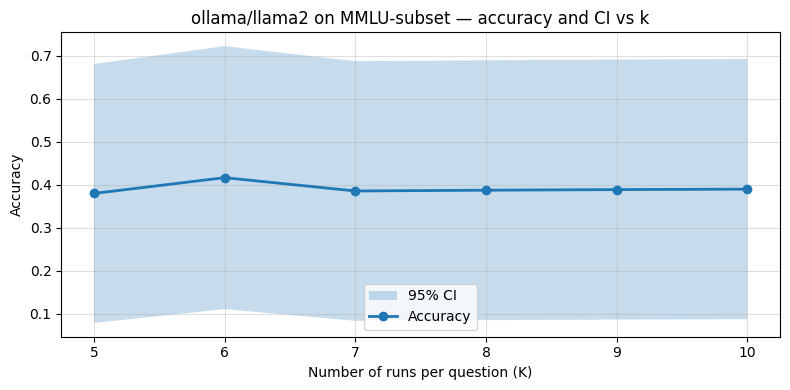

График сохранён: 2_week/4.1_ci_vs_k.png


In [ ]:
                                                                                                                                                 
# Сбрасываем списки перед запуском                                                                                                               
accuracies = []                                                                                                                                  
ci_lowers  = []                                                                                                                                  
ci_uppers  = []                                                                                                                                  
                                                    
# Для каждого K берём только первые K уникальных эпох
epoch_values_sorted = sorted(df_full["epoch"].unique())

for k in k_values:
    # Берём первые k эпох из доступных
    first_k_epochs = epoch_values_sorted[:k]
    df_k = df_full[df_full["epoch"].isin(first_k_epochs)]

    lo, acc, hi = ci_accuracy(df_k)
    accuracies.append(acc)
    ci_lowers.append(lo)
    ci_uppers.append(hi)

# Выводим числа для ответов на вопросы
print("\nK | Accuracy | CI width")
for k, acc, lo, hi in zip(k_values, accuracies, ci_lowers, ci_uppers):
    print(f"K={k}: {acc:.1%}  [{lo:.1%}, {hi:.1%}]  ширина={hi-lo:.3f}")

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("4.1_ci_vs_k.png", dpi=100)
plt.show()
print("График сохранён: 2_week/4.1_ci_vs_k.png")

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?
2. Does more K change your estimate of the model's accuracy, or just your confidence in it?
3. What does this tell you about how to allocate your evaluation budget?

**Your answer:**

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

In [ ]:
# Запускаем eval на всём MY_SUBSET (1 эпоха)
print(f"Запускаем eval на всём MY_SUBSET ({len(MY_SUBSET)} вопросов)...")
logs_full = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_A,
    epochs=1,
    max_connections=N_PARALLEL
)
df_all = log_to_df(logs_full[0])


ДИ < 10% начиная с n = 10
Размер MY_SUBSET: 272 вопросов
Ширина ДИ при n=272: 0.112


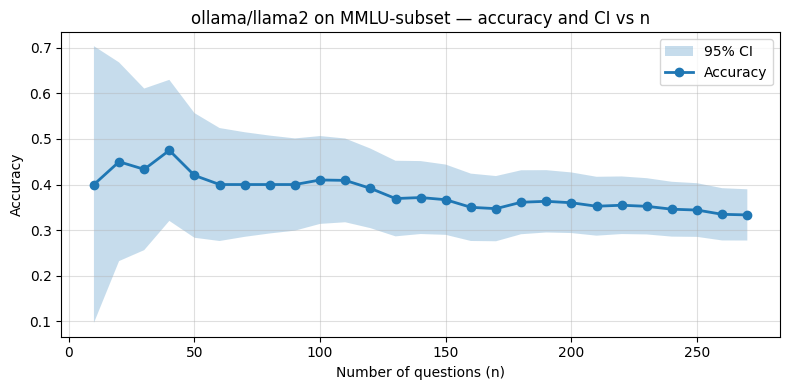

График сохранён: 2_week/4.2_ci_vs_n.png


In [30]:
# Все уникальные id вопросов — будем нарезать по ним
question_ids  = sorted(df_all["id"].unique())
dataset_sizes = range(10, len(question_ids) + 1, 10)

accuracies = []
ci_lowers  = []
ci_uppers  = []

# Для каждого n берём первые n вопросов и считаем ДИ
for n in dataset_sizes:
    first_n_ids = question_ids[:n]
    df_n = df_all[df_all["id"].isin(first_n_ids)]

    lo, acc, hi = ci_accuracy(df_n)
    accuracies.append(acc)
    ci_lowers.append(lo)
    ci_uppers.append(hi)

# Ключевые точки для ответов на вопросы
widths = [hi - lo for lo, hi in zip(ci_lowers, ci_uppers)]
stable_n = dataset_sizes.start  # ищем где ширина стабилизируется
for i, (n, w) in enumerate(zip(dataset_sizes, widths)):
    if w < 0.10:
        stable_n = n
        break

print(f"\nДИ < 10% начиная с n = {stable_n}")
print(f"Размер MY_SUBSET: {len(question_ids)} вопросов")
print(f"Ширина ДИ при n={len(question_ids)}: {widths[-1]:.3f}")

plt.figure(figsize=(8, 4))
plt.fill_between(list(dataset_sizes), ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(list(dataset_sizes), accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("4.2_ci_vs_т.png", dpi=100)
plt.show()
print("График сохранён: 2_week/4.2_ci_vs_n.png")

---
1. At what n does the accuracy line start to feel stable? 
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region? 
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:** 
1. ~120 вопросов 
2. да, 120 < 272. к 272 ДИ сужается 
3.  n напрямую сужает ДИ, каждый новый вопрос добавляет информацию о поведении модели на новой задаче. K отвечает за повторный "прогон" одного вопроса, снижает  случайность в ответах модели на уже увиденный вопрос (уточняет уже известное)

## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [14]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Запускает eval и возвращает средний score по каждому вопросу (отсортированный по id)."""
    print(f"  Запускаем {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs,
                    max_connections=N_PARALLEL)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Парный t-тест между двумя наборами оценок по вопросам.

    Возвращает (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "массивы должны покрывать одни и те же вопросы"

    alternative = "two-sided" if two_tailed else "greater"

    # stats.ttest_rel вычисляет d_i = scores1_i - scores2_i и тестирует mean(d) = 0
    _, p_value = stats.ttest_rel(scores1, scores2, alternative=alternative)
    mean_diff  = (scores1 - scores2).mean()

    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Запускает eval для обеих моделей и проводит парный t-тест.

    Возвращает (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [15]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


/Users/anyarulina/miniconda3/envs/botiki/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


In [16]:
# Реальное сравнение моделей на MY_SUBSET
print(f"\nСравниваем {MODEL_A} vs {MODEL_B} на professional_medicine...")
p_val, mean_diff, is_sig = compare_models_paired(MODEL_A, MODEL_B, MY_SUBSET)

print(f"\nРезультаты:")
print(f"  p-value:       {p_val:.4f}")
print(f"  Разница (A-B): {mean_diff:+.3f} ({mean_diff:+.1%})")
print(f"  Значимо?       {'ДА' if is_sig else 'НЕТ'} (alpha=0.05)")

if is_sig:
    winner = MODEL_A if mean_diff > 0 else MODEL_B
    print(f"  {winner} значимо лучше")
else:
    print("  Разница не выходит за пределы статистического шума")


Сравниваем ollama/llama2 vs ollama/qwen2:latest на professional_medicine...
  Запускаем ollama/llama2 ...


Output()

Output()

  Запускаем ollama/qwen2:latest ...



Результаты:
  p-value:       0.0000
  Разница (A-B): -0.371 (-37.1%)
  Значимо?       ДА (alpha=0.05)
  ollama/qwen2:latest значимо лучше


---
1. Write down the p-value and the mean difference you got.
2. Is the gap significant? Is it large enough to matter in practice?
3. What would change your conclusion: more questions, a different subject, or a different model pair?

**Your answer:**
1. p-value 0.0000 (< 0.0001), mean difference −0.371 (−37.1%)
2. Разница стат значима, вероятность получить такую разницу случайно крайне мала 
3. Большее количество вопросов сузило бы ДИ. Другая тема могла бы изменить вывод, если одна из моделей лучше обучена на эту тему. Другие модели также изменили бы вывод из-за разного размера и т.д.

## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [17]:
def ci_accuracy_for_difference(
    scores_a: np.ndarray,
    scores_b: np.ndarray,
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    ДИ на разницу средних точностей (A - B) через CLT.

    Разница d_i = score_A_i - score_B_i — не обязательно бинарная (∈ {-1, 0, 1}),
    поэтому используем выборочное стандартное отклонение, а не формулу Бернулли.

    Параметры
    ---------
    scores_a, scores_b : массивы средних оценок по вопросам
    ci : уровень доверия

    Возвращает
    ----------
    (нижняя граница, средняя разница, верхняя граница)
    """
    diff = scores_a - scores_b          # разница по каждому вопросу
    n = len(diff)
    mean_diff = diff.mean()

    # SE для непрерывных значений: выборочное std / sqrt(n)
    se = diff.std(ddof=1) / np.sqrt(n)
    z  = stats.norm.ppf((1 + ci) / 2)

    return mean_diff - z * se, mean_diff, mean_diff + z * se


# Запускаем обе модели на MY_SUBSET
print(f"Сравниваем {MODEL_A} vs {MODEL_B}...")
scores_a = run_and_get_scores(MODEL_A, MY_SUBSET)
scores_b = run_and_get_scores(MODEL_B, MY_SUBSET)

lo, diff, hi = ci_accuracy_for_difference(scores_a, scores_b)

print(f"\n95% ДИ на разницу точностей (A - B):")
print(f"  Средняя разница: {diff:+.3f} ({diff:+.1%})")
print(f"  Интервал:        [{lo:+.3f}, {hi:+.3f}]  ({lo:+.1%}, {hi:+.1%})")
print(f"  Содержит 0?      {'ДА → разница незначима' if lo <= 0 <= hi else 'НЕТ → разница значима'}")

print(f"\nИнтерпретация:")
if lo > 0:
    print(f"  {MODEL_A} лучше на {lo:.1%}–{hi:.1%} (с уверенностью 95%)")
elif hi < 0:
    print(f"  {MODEL_B} лучше на {-hi:.1%}–{-lo:.1%} (с уверенностью 95%)")
else:
    print(f"  Разница статистически незначима (ДИ включает 0)")


Output()

Сравниваем ollama/llama2 vs ollama/qwen2:latest...
  Запускаем ollama/llama2 ...


  Запускаем ollama/qwen2:latest ...


Output()


95% ДИ на разницу точностей (A - B):
  Средняя разница: -0.338 (-33.8%)
  Интервал:        [-0.409, -0.267]  (-40.9%, -26.7%)
  Содержит 0?      НЕТ → разница значима

Интерпретация:
  ollama/qwen2:latest лучше на 26.7%–40.9% (с уверенностью 95%)


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:**
1. [−40.9%, −26.7%], ноль не содержит.
2. Да, они говорят об одной и той же стат значимой разнице, но с разной степенью детализации.
3. Интервал информативнее. p-value даёт качественный ответ, интервал - количественный. Потому что показывает величину разницы.

## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [18]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Оценивает omega2, sigma2_a, sigma2_b из двух EvalLog (см. §5 Miller 2024).

    Оба лога должны покрывать одни и те же вопросы.
    Нужно epochs >= 2, чтобы оценить внутривопросную дисперсию.

    Возвращает dict с ключами 'omega2', 'sigma2_a', 'sigma2_b'.
    """
    df_a = log_to_df(logs_a[0])
    df_b = log_to_df(logs_b[0])

    # Число эпох для каждой модели
    k_a = df_a["epoch"].nunique()
    k_b = df_b["epoch"].nunique()

    # Среднее score по эпохам для каждого вопроса
    # p̂_A_i — оценка вероятности правильного ответа модели A на вопрос i
    pa = df_a.groupby("id")["score"].mean()
    pb = df_b.groupby("id")["score"].mean()

    # Берём только общие вопросы
    common = pa.index.intersection(pb.index)
    pa = pa.loc[common]
    pb = pb.loc[common]

    # σ̂²_A = среднее Бернулли-дисперсий: E[p*(1-p)]
    # Бернулли-дисперсия = "насколько стохастична модель на этом вопросе"
    sigma2_a = (pa * (1 - pa)).mean()
    sigma2_b = (pb * (1 - pb)).mean()

    # Разница по каждому вопросу: d̂_i = p̂_A_i - p̂_B_i
    d = pa - pb

    # Выборочная дисперсия разниц — включает и истинную ω², и шум выборки
    var_d = d.var(ddof=1)

    # Вычитаем шум выборки (метод моментов): ω̂² = Var(d̂) - σ²_A/K_A - σ²_B/K_B
    # max(0, ...) — дисперсия не может быть отрицательной
    omega2 = float(max(0.0, var_d - sigma2_a / k_a - sigma2_b / k_b))

    return {
        "omega2":   omega2,
        "sigma2_a": float(sigma2_a),
        "sigma2_b": float(sigma2_b),
    }


def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE для парного сравнения моделей (Eq. 10 из Miller 2024)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [19]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Running pilot evals ...


Output()

Output()

omega2  = 0.2845
sigma2_A = 0.0167
sigma2_B = 0.0333

With n=272 questions -> MDE = 9.8%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**
1. MDE = 9.8% (80% мощность, α=0.05). Если с текущим датасетом мы гарантированно обнаружим разрыв между моделями от 9.8% и выше, то разрыв в ~10% для медицинского бенчмарка практически значим. Разница в 10% имеет реальные последствия. 

omega2 = 0.2845 - дисперсия разрыва между моделями от вопроса к вопросу.
sigma2_A = 0.0167 - стохастичность llama2, если задать одной модели один и тот же вопрос дважды, насколько часто ответ меняется. очень маленькое значение значит, что llama2 отвечает почти одинаково при повторных запусках.                                             
sigma2_B = 0.0333 - то же для qwen2, тоже маленькое. qwen2 чуть менее стабильна, чем llama2, но всё равно очень последовательна.
omega2 (0.28) в 8–17 раз больше sigma2 (0.017 и 0.033). Это значит: неопределённость в нашей оценке разрыва между моделями почти полностью объясняется тем, что мы видели мало вопросов, а не тем, что модели непоследовательны. Поэтому единственный способ снизить MDE — брать больше вопросов (n), а не больше эпох (K).

2. Наш датасет с запасом достаточен для обнаружения разницы. Если бы MDE был больше 37.1%, это означало бы, что мы нашли значимый результат, но наш тест был слишком слаб, чтобы ему доверять.

## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [20]:
def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """
    Минимальное число вопросов для обнаружения разрыва delta при заданной мощности.

    Из MDE = (z_α + z_β) * sqrt(V/n), где V = ω² + σ²_A/K_A + σ²_B/K_B,
    выражаем n: n = (z_α + z_β)² * V / delta²
    """
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)

    V = omega2 + sigma2_a / ka + sigma2_b / kb   # суммарная дисперсия

    # Решаем формулу MDE относительно n
    n = (z_alpha + z_beta) ** 2 * V / delta ** 2

    return int(np.ceil(n))  # округляем вверх — нужно не меньше n вопросов


# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

Questions needed to detect delta=5%: 1051
Round-trip check passed!


In [21]:
# Практические расчёты
n5  = required_sample_size(delta=0.05, **params)
n10 = required_sample_size(delta=0.10, **params)

print(f"\nПрактические расчёты для MY_SUBSET (professional_medicine):")
print(f"  Вопросов для delta = 5%:  {n5}")
print(f"  Вопросов для delta = 10%: {n10}")
print(f"  Размер MY_SUBSET: {len(MY_SUBSET)}")
print(f"  MY_SUBSET {'достаточен' if len(MY_SUBSET) >= n5 else 'недостаточен'} для обнаружения 5% разрыва")
print(f"  MY_SUBSET {'достаточен' if len(MY_SUBSET) >= n10 else 'недостаточен'} для обнаружения 10% разрыва")


Практические расчёты для MY_SUBSET (professional_medicine):
  Вопросов для delta = 5%:  1051
  Вопросов для delta = 10%: 263
  Размер MY_SUBSET: 272
  MY_SUBSET недостаточен для обнаружения 5% разрыва
  MY_SUBSET достаточен для обнаружения 10% разрыва


---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:**
1. для delta = 5%:  1051, для delta = 10%: 263 
2. для 10% достаточен, для 5% - нет. 

Для сравнения именно llama2 и qwen2 датасет полностью достаточен: реальный разрыв между ними 37%, что в 3–4 раза превышает MDE. Но если бы мы сравнивали две близкие модели с разрывом 5–8%, наш датасет был бы слишком мал и мы рисковали бы не обнаружить реальную разницу (ошибка II рода).


## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [ ]:
# Запускаем одну и ту же модель с двумя разными solver'ами на одних и тех же вопросах
MODEL = MODEL_A  # можно заменить на MODEL_B

print(f"Запускаем baseline для {MODEL}...")
logs_baseline = eval(mmlu_subset(MY_SUBSET), model=MODEL, max_connections=N_PARALLEL)
df_baseline   = log_to_df(logs_baseline[0])
scores_baseline = df_baseline.groupby("id")["score"].mean().sort_index().values

In [25]:
# Запускаем baseline для ollama/llama2...
# ╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
# │mmlu_subset (272 samples): ollama/llama2                                                                         │
# ╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
# max_connections: 2, subset: cais/mmlu, dataset: cais/mmlu                                                          
                                                                                                                   
# total time:                     0:36:30                                                                            
# ollama/llama2                   85,459 tokens [I: 79,878, O: 5,581]                                                
                                                                                                                   
# choice                                                                                                             
# accuracy  0.312                                                                                                    
# stderr    0.028                                                                                                    
                                                                                                                   
# Log: logs/2026-04-14T17-14-51-00-00_mmlu-subset_2kaC7kY9QXcvJhj6PyvUis.eval      

# ╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
# │mmlu_subset (272 samples): ollama/llama2                                                                         │
# ╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
# max_connections: 2, subset: cais/mmlu, dataset: cais/mmlu                                                          
                                                                                                                   
# total time:                     0:36:30                                                                            
# ollama/llama2                   85,459 tokens [I: 79,878, O: 5,581]                                                
                                                                                                                   
# choice                                                                                                             
# accuracy  0.312                                                                                                    
# stderr    0.028                                                                                                    
                                                                                                                   
# Log: logs/2026-04-14T17-14-51-00-00_mmlu-subset_2kaC7kY9QXcvJhj6PyvUis.eval        

In [27]:
from inspect_ai.solver import chain_of_thought
                                            
@task                                   
def mmlu_cot(subset):
    """Task с chain-of-thought: сначала рассуждение, затем выбор ответа."""                                                     
    return Task(                            
        dataset=subset,                                                                                                         
        solver=[chain_of_thought(), multiple_choice()],
        scorer=choice()                                                                                                         
    ) 

In [28]:

print(f"Запускаем chain-of-thought для {MODEL}...")
logs_cot    = eval(mmlu_cot(MY_SUBSET), model=MODEL, max_connections=N_PARALLEL)
df_cot      = log_to_df(logs_cot[0])
scores_cot  = df_cot.groupby("id")["score"].mean().sort_index().values

# Выравниваем по общим вопросам (на случай если id не совпадают)
ids_baseline = df_baseline.groupby("id")["score"].mean().sort_index().index
ids_cot      = df_cot.groupby("id")["score"].mean().sort_index().index
common_ids   = ids_baseline.intersection(ids_cot)

scores_baseline = df_baseline[df_baseline["id"].isin(common_ids)].groupby("id")["score"].mean().sort_index().values
scores_cot      = df_cot[df_cot["id"].isin(common_ids)].groupby("id")["score"].mean().sort_index().values

# Парный t-тест: CoT лучше baseline?
p_val, mean_diff, is_sig = significance_by_paired_ttest(scores_cot, scores_baseline)

acc_baseline = scores_baseline.mean()
acc_cot      = scores_cot.mean()

print(f"\nРезультаты для {MODEL} на professional_medicine:")
print(f"  Baseline accuracy:   {acc_baseline:.1%}")
print(f"  CoT accuracy:        {acc_cot:.1%}")
print(f"  Разница (CoT-Base):  {mean_diff:+.3f} ({mean_diff:+.1%})")
print(f"  p-value:             {p_val:.4f}")
print(f"  Значимо?             {'ДА' if is_sig else 'НЕТ'} (alpha=0.05)")

if is_sig and mean_diff > 0:
    print(f"\n  ✓ Chain-of-thought значимо улучшает точность на {mean_diff:.1%}")
elif is_sig and mean_diff < 0:
    print(f"\n  ✗ Chain-of-thought значимо УХУДШАЕТ точность на {abs(mean_diff):.1%}")
else:
    print(f"\n  ~ Разница между baseline и CoT статистически незначима")


Запускаем chain-of-thought для ollama/llama2...


Output()


Результаты для ollama/llama2 на professional_medicine:
  Baseline accuracy:   31.2%
  CoT accuracy:        27.9%
  Разница (CoT-Base):  -0.033 (-3.3%)
  p-value:             0.3241
  Значимо?             НЕТ (alpha=0.05)

  ~ Разница между baseline и CoT статистически незначима


---
1. Does chain-of-thought help? By how much, and is it significant?
2. Does the result surprise you? What might explain it?
3. Would you expect the same pattern on a different subject?

**Your answer:**

## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?

In [44]:
def ci_accuracy_clustered(
    scores: np.ndarray,
    cluster_ids: np.ndarray,
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    Кластеризованный ДИ для точности (Eq. 4 из Miller 2024).

    Учитывает корреляцию вопросов внутри одного кластера (текста).
    SE рассчитывается как sandwich-оценка: суммируем "вклады" кластеров,
    а не отдельных вопросов.

    Параметры
    ---------
    scores      : массив из 0 и 1 по каждому вопросу
    cluster_ids : метка кластера для каждого вопроса
    ci          : уровень доверия

    Возвращает
    ----------
    (нижняя граница, средняя точность, верхняя граница)
    """
    n = len(scores)
    x_bar = scores.mean()
    residuals = scores - x_bar   # отклонение каждого ответа от среднего

    # Sandwich SE: для каждого кластера суммируем его остатки,
    # затем суммируем квадраты этих сумм
    cluster_sums_sq = 0.0
    for cid in np.unique(cluster_ids):
        mask = (cluster_ids == cid)
        cluster_sum = residuals[mask].sum()   # сумма остатков в кластере
        cluster_sums_sq += cluster_sum ** 2

    # SE = sqrt(1/n² * Σ_c S_c²)
    se = np.sqrt(cluster_sums_sq) / n
    z  = stats.norm.ppf((1 + ci) / 2)

    return x_bar - z * se, x_bar, x_bar + z * se


def ci_paired_clustered(
    scores_a: np.ndarray,
    scores_b: np.ndarray,
    cluster_ids: np.ndarray,
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    Кластеризованный ДИ на разницу точностей (Eq. 8 из Miller 2024).
    """
    diff = scores_a - scores_b
    return ci_accuracy_clustered(diff, cluster_ids, ci)


# === ДЕМОНСТРАЦИЯ: создаём синтетические кластеризованные данные ===
# (Если нет доступа к RACE, демонстрируем на симуляции)

np.random.seed(42)
n_clusters   = 20   # 20 текстов
q_per_cluster = 5   # 5 вопросов к каждому тексту
n_total = n_clusters * q_per_cluster

# Симулируем: у каждого текста своя сложность (p_cluster),
# и модель стохастична внутри текста
cluster_ids = np.repeat(np.arange(n_clusters), q_per_cluster)
p_clusters  = np.random.uniform(0.3, 0.9, n_clusters)  # сложность каждого текста
p_questions = p_clusters[cluster_ids]                   # сложность каждого вопроса
scores_sim  = np.random.binomial(1, p_questions).astype(float)

# Наивный CLT ДИ
lo_naive, acc, hi_naive = ci_accuracy_basic(scores_sim)

# Кластеризованный ДИ
lo_clust, _, hi_clust = ci_accuracy_clustered(scores_sim, cluster_ids)

print("=== Демонстрация: симулированные данные ===")
print(f"n = {n_total} вопросов в {n_clusters} кластерах по {q_per_cluster} вопросов")
print(f"\nAccuracy: {acc:.1%}")
print(f"Наивный CLT ДИ:       [{lo_naive:.1%}, {hi_naive:.1%}]  ширина={hi_naive-lo_naive:.3f}")
print(f"Кластеризованный ДИ:  [{lo_clust:.1%}, {hi_clust:.1%}]  ширина={hi_clust-lo_clust:.3f}")
print(f"\nКластеризованный ДИ {'шире' if (hi_clust-lo_clust) > (hi_naive-lo_naive) else 'у́же'} — "
      f"отношение: {(hi_clust-lo_clust)/(hi_naive-lo_naive):.2f}x")
print("(Должен быть шире: внутрикластерная корреляция уменьшает эффективный размер выборки)")

# Парное сравнение с кластеризованным SE
scores_b_sim = np.random.binomial(1, p_questions * 0.9).astype(float)  # модель B немного хуже
lo_paired, diff_paired, hi_paired = ci_paired_clustered(scores_sim, scores_b_sim, cluster_ids)
lo_naive_p, diff_naive_p, hi_naive_p = ci_accuracy_basic(scores_sim - scores_b_sim)

print(f"\n=== Парное сравнение A vs B ===")
print(f"Наивный ДИ на разницу:        [{lo_naive_p:.3f}, {hi_naive_p:.3f}]")
print(f"Кластеризованный ДИ на разницу: [{lo_paired:.3f}, {hi_paired:.3f}]")
print(f"Наивный ДИ содержит 0?        {'ДА → незначимо' if lo_naive_p<=0<=hi_naive_p else 'НЕТ → значимо'}")
print(f"Кластеризованный ДИ содержит 0? {'ДА → незначимо' if lo_paired<=0<=hi_paired else 'НЕТ → значимо'}")


=== Демонстрация: симулированные данные ===
n = 100 вопросов в 20 кластерах по 5 вопросов

Accuracy: 62.0%
Наивный CLT ДИ:       [52.5%, 71.5%]  ширина=0.190
Кластеризованный ДИ:  [50.6%, 73.4%]  ширина=0.228

Кластеризованный ДИ шире — отношение: 1.20x
(Должен быть шире: внутрикластерная корреляция уменьшает эффективный размер выборки)

=== Парное сравнение A vs B ===
Наивный ДИ на разницу:        [0.034, 0.146]
Кластеризованный ДИ на разницу: [-0.038, 0.218]
Наивный ДИ содержит 0?        НЕТ → значимо
Кластеризованный ДИ содержит 0? ДА → незначимо
